# Прогнозування вартості готельних номерів для платформи Golobe

**Автор:** Талаєвич Назар Олегович
**Група:** ІПЗс-22-1
**Курс:** Introduction to Machine Learning for Data Science 
**Дата:** 06.05.2026

---

## Опис проєкту

**Мета:** Розробити модель машинного навчання для прогнозування ціни за ніч (ADR — Average Daily Rate) у готелях. Це дозволить туристичному асистенту Golobe надавати користувачам очікувану вартість проживання під час планування подорожі.

**Тип задачі:** Регресія (прогнозування числового значення — ціни)

**Джерело даних:** [Hotel Booking Demand (Kaggle)](https://www.kaggle.com/datasets/jessemostipak/hotel-booking-demand) — датасет містить реальні параметри бронювань у португальських готелях за 2015–2017 роки (~119 000 записів). Обраний через відкритий доступ, реалістичні ознаки та задокументоване походження даних.

---

## Структура проєкту

1. Завантаження та очищення даних
2. Експлораторний аналіз (EDA)
3. Підготовка даних (Feature Engineering)
4. Навчання та порівняння моделей
5. Оцінка якості
6. Висновки та подальше використання

## 1. Завантаження та очищення даних

На цьому етапі завантажуємо датасет і виконуємо первинне очищення:

- Видаляємо колонки `company` та `agent` — понад 90% значень відсутні, вони не несуть значущої інформації.
- Заповнюємо пропуски в `children` нулем (відсутній запис = 0 дітей).
- Заповнюємо пропуски в `country` значенням `'Unknown'`.
- Видаляємо аномалії: нульові ціни (технічні записи / помилки) та ціни понад 1000 € (статистичні викиди, що спотворюють модель).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

try:
    df = pd.read_csv('hotel_bookings.csv')
    print(f"Дані завантажено. Розмір: {df.shape[0]} рядків, {df.shape[1]} колонок")
except FileNotFoundError:
    print("Файл 'hotel_bookings.csv' не знайдено. Завантажте датасет з Kaggle.")

Дані завантажено. Розмір: 119390 рядків, 32 колонок


In [2]:
print("--- Пропущені значення (топ-10) ---")
missing = df.isnull().sum().sort_values(ascending=False)
print(missing[missing > 0])

print(f"\n--- Типи даних ---")
print(df.dtypes.value_counts())

--- Пропущені значення (топ-10) ---
company     112593
agent        16340
country        488
children         4
dtype: int64

--- Типи даних ---
int64      16
object     12
float64     4
Name: count, dtype: int64


In [3]:
df = df.drop(['company', 'agent'], axis=1)
df['children'] = df['children'].fillna(0).astype(int)
df['country'] = df['country'].fillna('Unknown')

initial_count = len(df)
df = df[(df['adr'] > 0) & (df['adr'] < 1000)]
removed = initial_count - len(df)

print(f"Видалено аномальних записів: {removed} ({removed/initial_count*100:.1f}%)")
print(f"Залишилось для аналізу: {len(df)} записів")
print(f"\nПропущені значення після очищення: {df.isnull().sum().sum()}")

Видалено аномальних записів: 1961 (1.6%)
Залишилось для аналізу: 117429 записів

Пропущені значення після очищення: 0


## 2. Експлораторний аналіз даних (EDA)

Мета: зрозуміти структуру та розподіл даних, виявити закономірності, що впливають на ціну.

Аналізуємо:
- Описову статистику числових змінних
- Розподіл цільової змінної ADR
- Залежність ціни від типу готелю та сезонності
- Матрицю кореляцій
- Аномалії та баланс категорій

In [4]:
print("=== Описова статистика числових змінних ===")
desc = df.describe().round(2)
display(desc)

=== Описова статистика числових змінних ===


,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,117429.00,117429.00,117429.00,117429.00,117429.00,117429.00,117429.00,117429.00,117429.0,117429.00,117429.00,117429.00,117429.00,117429.00,117429.00,117429.00,117429.00,117429.00
mean,0.37,105.08,2016.16,27.14,15.80,0.94,2.52,1.86,0.1,0.01,0.03,0.09,0.13,0.22,2.34,103.49,0.06,0.57
std,0.48,106.91,0.71,13.58,8.78,1.00,1.89,0.48,0.4,0.10,0.16,0.85,1.45,0.63,17.68,46.71,0.25,0.79
min,0.00,0.00,2015.00,1.00,1.00,0.00,0.00,0.00,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.26,0.00,0.00
25%,0.00,19.00,2016.00,16.00,8.00,0.00,1.00,2.00,0.0,0.00,0.00,0.00,0.00,0.00,0.00,70.53,0.00,0.00
50%,0.00,71.00,2016.00,27.00,16.00,1.00,2.00,2.00,0.0,0.00,0.00,0.00,0.00,0.00,0.00,95.00,0.00,0.00
75%,1.00,162.00,2017.00,38.00,23.00,2.00,3.00,2.00,0.0,0.00,0.00,0.00,0.00,0.00,0.00,126.00,0.00,1.00
max,1.00,709.00,2017.00,53.00,31.00,19.00,50.00,4.00,10.0,10.00,1.00,26.00,72.00,18.00,391.00,510.00,8.00,5.00


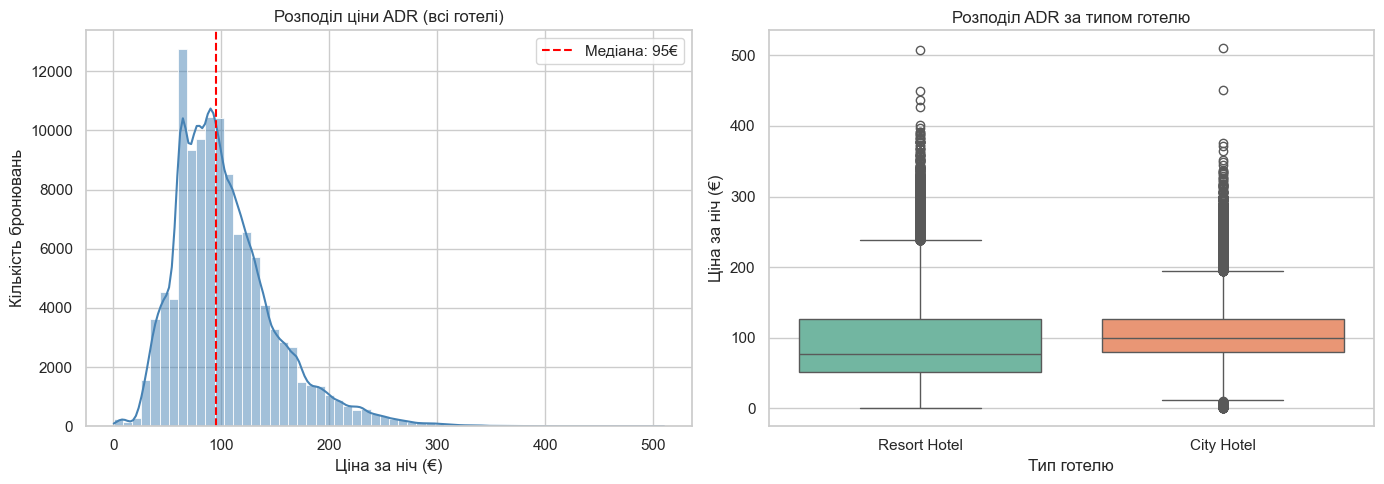

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['adr'], bins=60, kde=True, color='steelblue', ax=axes[0])
axes[0].set_title('Розподіл ціни ADR (всі готелі)')
axes[0].set_xlabel('Ціна за ніч (€)')
axes[0].set_ylabel('Кількість бронювань')
axes[0].axvline(df['adr'].median(), color='red', linestyle='--', label=f'Медіана: {df["adr"].median():.0f}€')
axes[0].legend()

sns.boxplot(data=df, x='hotel', y='adr', palette='Set2', ax=axes[1])
axes[1].set_title('Розподіл ADR за типом готелю')
axes[1].set_xlabel('Тип готелю')
axes[1].set_ylabel('Ціна за ніч (€)')

plt.tight_layout()
plt.show()

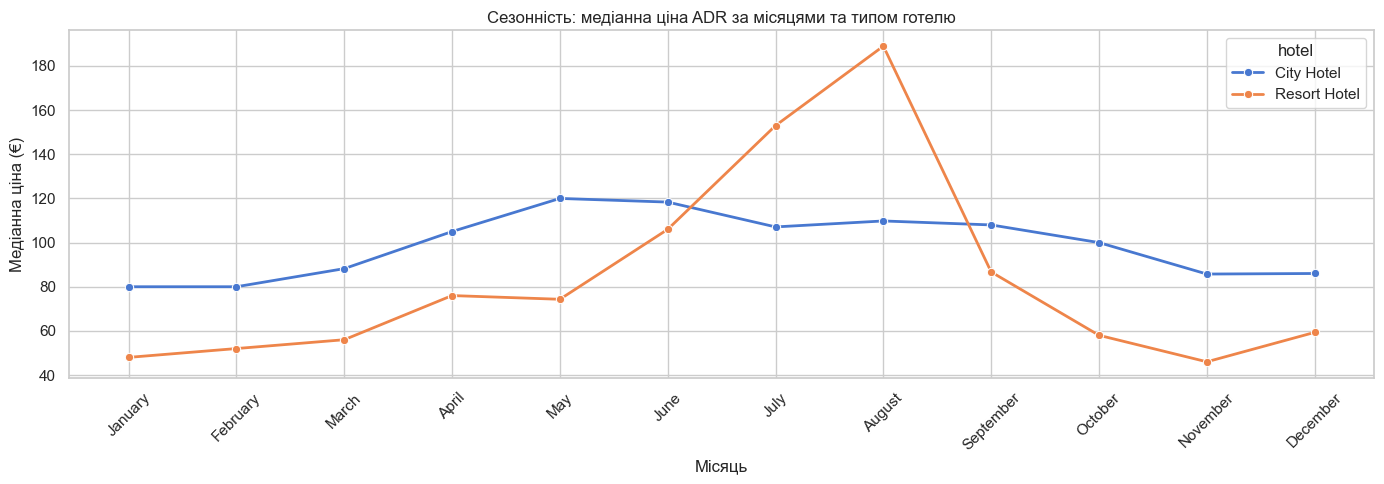

In [20]:
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']

monthly_adr = df.groupby(['arrival_date_month', 'hotel'])['adr'].median().reset_index()
monthly_adr['arrival_date_month'] = pd.Categorical(monthly_adr['arrival_date_month'],
                                                    categories=month_order, ordered=True)
monthly_adr = monthly_adr.sort_values('arrival_date_month')

plt.figure(figsize=(14, 5))
sns.lineplot(data=monthly_adr, x='arrival_date_month', y='adr',
             hue='hotel', marker='o', linewidth=2)
plt.title('Сезонність: медіанна ціна ADR за місяцями та типом готелю')
plt.xlabel('Місяць')
plt.ylabel('Медіанна ціна (€)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

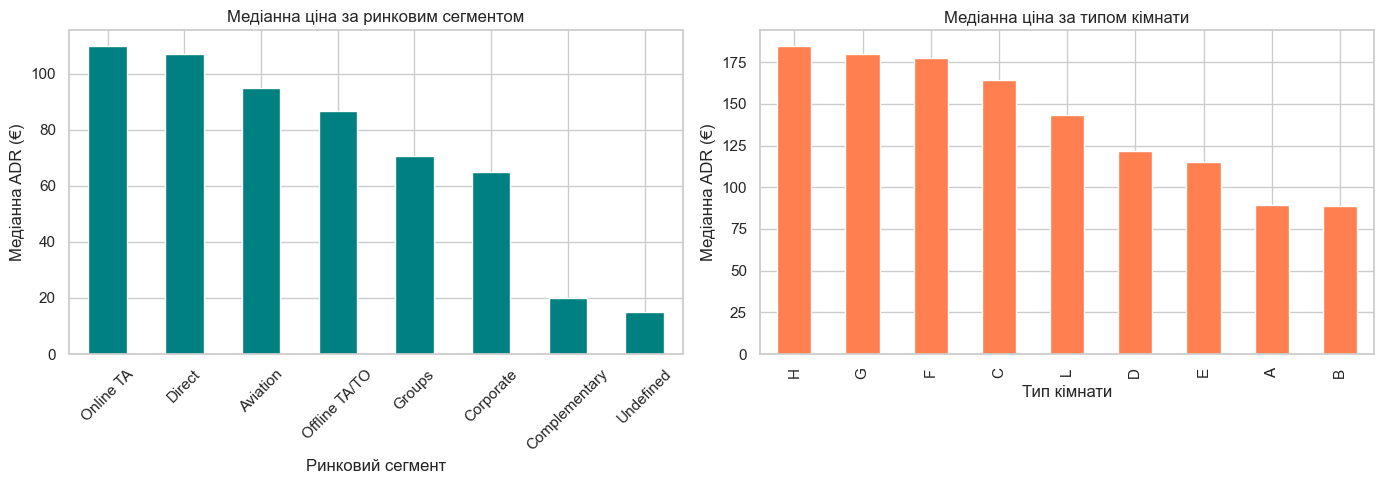

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

segment_adr = df.groupby('market_segment')['adr'].median().sort_values(ascending=False)
segment_adr.plot(kind='bar', ax=axes[0], color='teal')
axes[0].set_title('Медіанна ціна за ринковим сегментом')
axes[0].set_xlabel('Ринковий сегмент')
axes[0].set_ylabel('Медіанна ADR (€)')
axes[0].tick_params(axis='x', rotation=45)

room_adr = df.groupby('reserved_room_type')['adr'].median().sort_values(ascending=False)
room_adr.plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Медіанна ціна за типом кімнати')
axes[1].set_xlabel('Тип кімнати')
axes[1].set_ylabel('Медіанна ADR (€)')

plt.tight_layout()
plt.show()

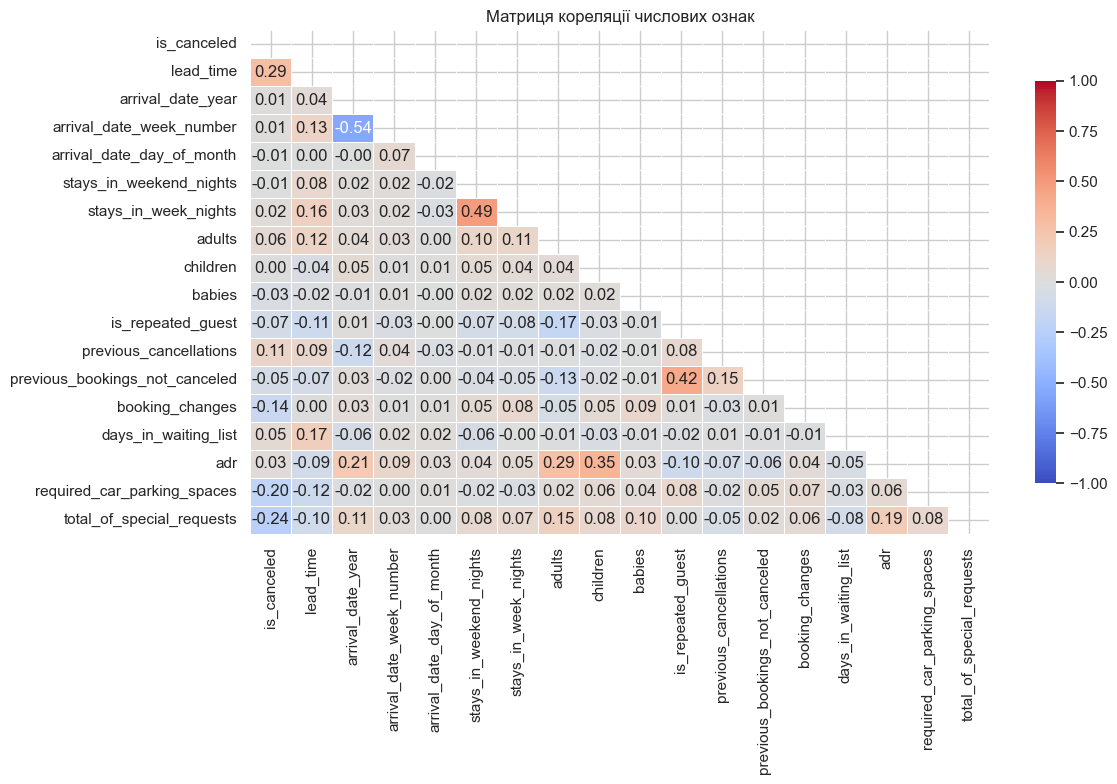


Найсильніші кореляції з ADR:
children                     0.353151
adults                       0.285119
arrival_date_year            0.206171
total_of_special_requests    0.191285
is_repeated_guest            0.103189
lead_time                    0.090969
arrival_date_week_number     0.089192
previous_cancellations       0.071314
Name: adr, dtype: float64


In [18]:
plt.figure(figsize=(12, 8))
numeric_df = df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, vmin=-1, vmax=1,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Матриця кореляції числових ознак')
plt.tight_layout()
plt.show()

print("\nНайсильніші кореляції з ADR:")
print(corr_matrix['adr'].drop('adr').abs().sort_values(ascending=False).head(8))

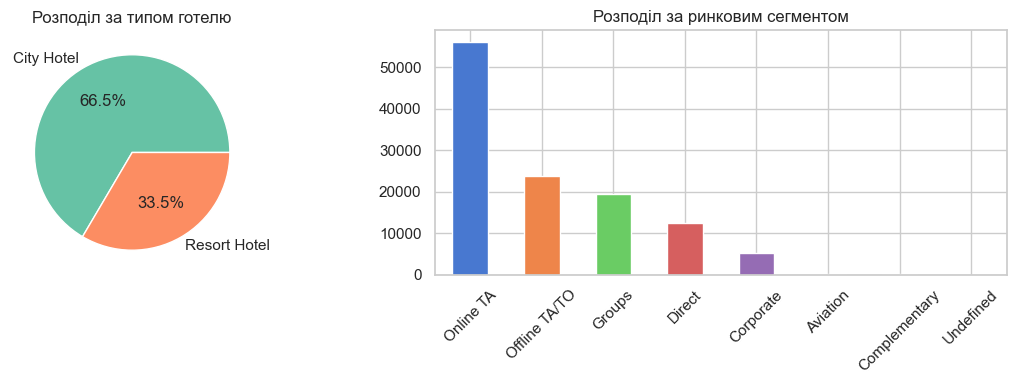


Висновок EDA:
  City Hotel дорожчий в середньому: City=100.0€, Resort=76.8€
  Пік цін: літо (червень–серпень)
  Найдорожчий сегмент: Online TA (110€)


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

hotel_counts = df['hotel'].value_counts()
axes[0].pie(hotel_counts, labels=hotel_counts.index, autopct='%1.1f%%',
            colors=sns.color_palette('Set2', 2))
axes[0].set_title('Розподіл за типом готелю')

segment_counts = df['market_segment'].value_counts()
segment_counts.plot(kind='bar', ax=axes[1], color=sns.color_palette('muted', len(segment_counts)))
axes[1].set_title('Розподіл за ринковим сегментом')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("\nВисновок EDA:")
print(f"  City Hotel дорожчий в середньому: City={df[df.hotel=='City Hotel']['adr'].median():.1f}€, "
      f"Resort={df[df.hotel=='Resort Hotel']['adr'].median():.1f}€")
print(f"  Пік цін: літо (червень–серпень)")
print(f"  Найдорожчий сегмент: {segment_adr.index[0]} ({segment_adr.iloc[0]:.0f}€)")

## 3. Підготовка даних (Feature Engineering)

Відбираємо ознаки, що мають найбільший вплив на ціну (на основі EDA та доменних знань):

- `hotel` — тип готелю (City / Resort)
- `arrival_date_month` — місяць приїзду (сезонність)
- `market_segment` — ринковий сегмент (Direct, Online TA тощо)
- `reserved_room_type` — тип кімнати
- `is_repeated_guest` — чи повторний гість
- `lead_time` — кількість днів між бронюванням і заїздом
- `stays_in_weekend_nights`, `stays_in_week_nights` — тривалість перебування
- `adults`, `children`, `babies` — кількість гостей

Категорійні ознаки перетворюємо за допомогою One-Hot Encoding (`pd.get_dummies`). Числові ознаки масштабуємо для Linear Regression (StandardScaler).

In [10]:
categorical_features = ['hotel', 'arrival_date_month', 'market_segment', 'reserved_room_type']
numeric_features = ['is_repeated_guest', 'lead_time', 'stays_in_weekend_nights',
                    'stays_in_week_nights', 'adults', 'children', 'babies']

all_features = categorical_features + numeric_features

X_cat = pd.get_dummies(df[categorical_features], drop_first=False)
X_num = df[numeric_features].copy()
X = pd.concat([X_cat, X_num], axis=1)
y = df['adr']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_test_scaled[numeric_features] = scaler.transform(X_test[numeric_features])

print(f"Кількість ознак після кодування: {X.shape[1]}")
print(f"Тренувальна вибірка: {X_train.shape[0]} записів")
print(f"Тестова вибірка: {X_test.shape[0]} записів")

Кількість ознак після кодування: 38
Тренувальна вибірка: 93943 записів
Тестова вибірка: 23486 записів


## 4. Навчання та порівняння моделей

Порівнюємо три алгоритми:

1. **Linear Regression** — базовий лінійний метод, простий та інтерпретований. Очікуємо нижчу точність через нелінійну природу даних.
2. **Random Forest Regressor** — ансамбль дерев рішень. Добре справляється з нелінійними залежностями та взаємодіями між ознаками.
3. **Gradient Boosting Regressor** — послідовний ансамбль, оптимізує залишкові помилки. Зазвичай показує найвищу точність, але потребує більше часу навчання.

**Метрики оцінки:**
- MAE (Mean Absolute Error) — середня абсолютна помилка в євро (зрозуміла для бізнесу)
- RMSE (Root Mean Squared Error) — штрафує великі помилки
- R² Score — частка поясненої дисперсії (1.0 = ідеальна модель)

In [16]:
models = {
    "Linear Regression": (LinearRegression(), X_train_scaled, X_test_scaled),
    "Random Forest": (RandomForestRegressor(n_estimators=100, max_depth=12, random_state=42, n_jobs=-1), X_train, X_test),
    "Gradient Boosting": (GradientBoostingRegressor(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42), X_train, X_test)
}

results = []
trained_models = {}
predictions = {}

for name, (model, X_tr, X_te) in models.items():
    print(f"Навчання: {name}...")
    model.fit(X_tr, y_train)
    preds = model.predict(X_te)
    
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    
    results.append({'Модель': name, 'MAE (€)': round(mae, 2), 'RMSE (€)': round(rmse, 2), 'R² Score': round(r2, 4)})
    trained_models[name] = model
    predictions[name] = preds

results_df = pd.DataFrame(results)
print("\n=== Результати оцінки якості ===")
display(results_df)

Навчання: Linear Regression...
Навчання: Random Forest...
Навчання: Gradient Boosting...

=== Результати оцінки якості ===


,Модель,MAE (€),RMSE (€),R² Score
0,Linear Regression,23.65,31.88,0.5380
1,Random Forest,15.97,22.98,0.7599
2,Gradient Boosting,17.56,24.09,0.7362


## 5. Оцінка якості та аналіз результатів

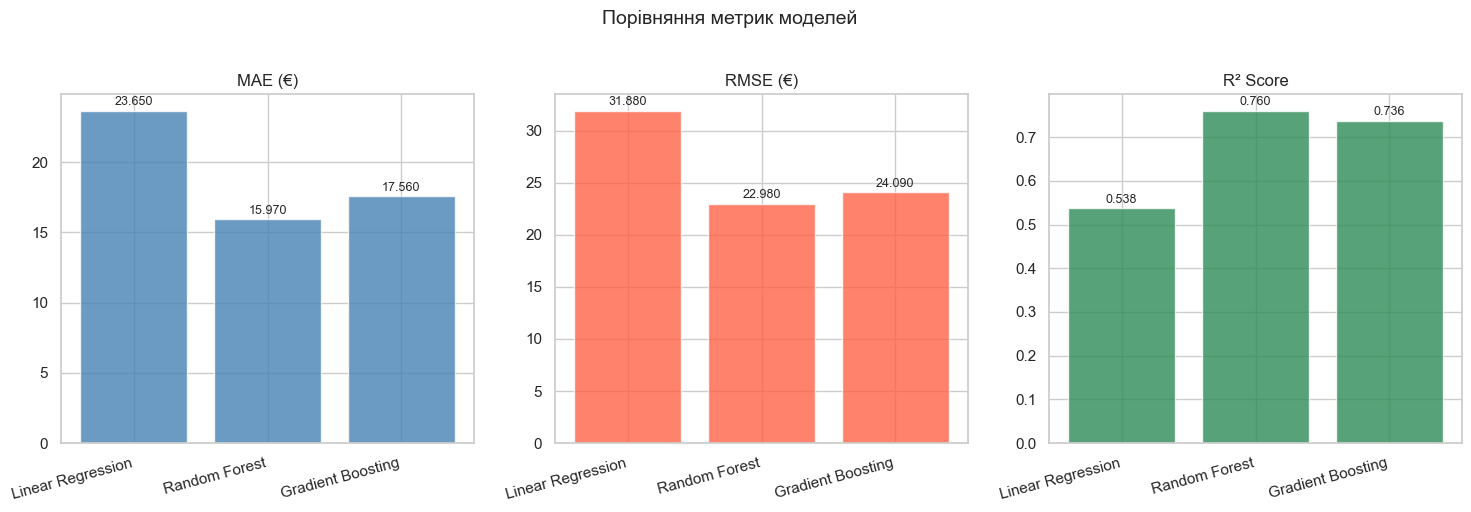

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metrics = ['MAE (€)', 'RMSE (€)', 'R² Score']
colors = ['steelblue', 'tomato', 'seagreen']

for i, (metric, color) in enumerate(zip(metrics, colors)):
    bars = axes[i].bar(results_df['Модель'], results_df[metric], color=color, alpha=0.8)
    axes[i].set_title(f'{metric}')
    axes[i].set_xticklabels(results_df['Модель'], rotation=15, ha='right')
    for bar in bars:
        h = bar.get_height()
        axes[i].text(bar.get_x() + bar.get_width()/2., h + 0.01*h,
                     f'{h:.3f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Порівняння метрик моделей', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

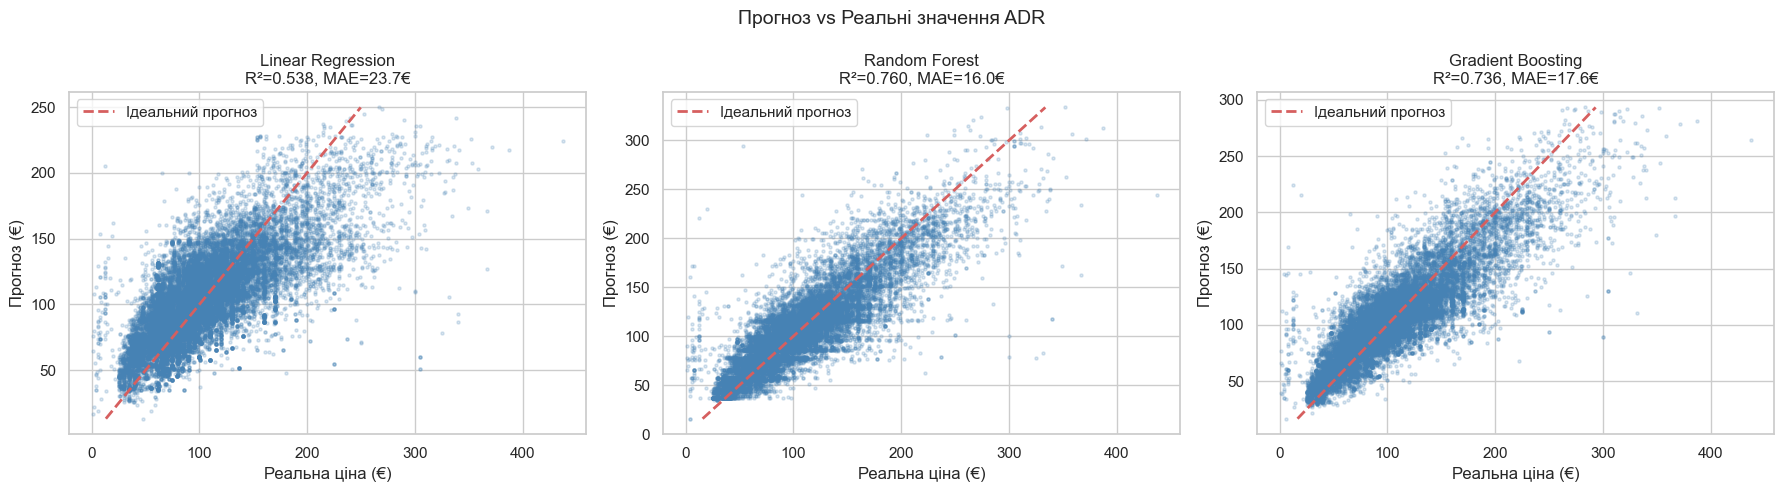

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, name in enumerate(models.keys()):
    preds = predictions[name]
    axes[i].scatter(y_test, preds, alpha=0.2, s=5, color='steelblue')
    lims = [max(y_test.min(), preds.min()), min(y_test.max(), preds.max())]
    axes[i].plot(lims, lims, '--r', lw=2, label='Ідеальний прогноз')
    axes[i].set_title(f'{name}\nR²={r2_score(y_test, preds):.3f}, MAE={mean_absolute_error(y_test, preds):.1f}€')
    axes[i].set_xlabel('Реальна ціна (€)')
    axes[i].set_ylabel('Прогноз (€)')
    axes[i].legend()

plt.suptitle('Прогноз vs Реальні значення ADR', fontsize=14)
plt.tight_layout()
plt.show()

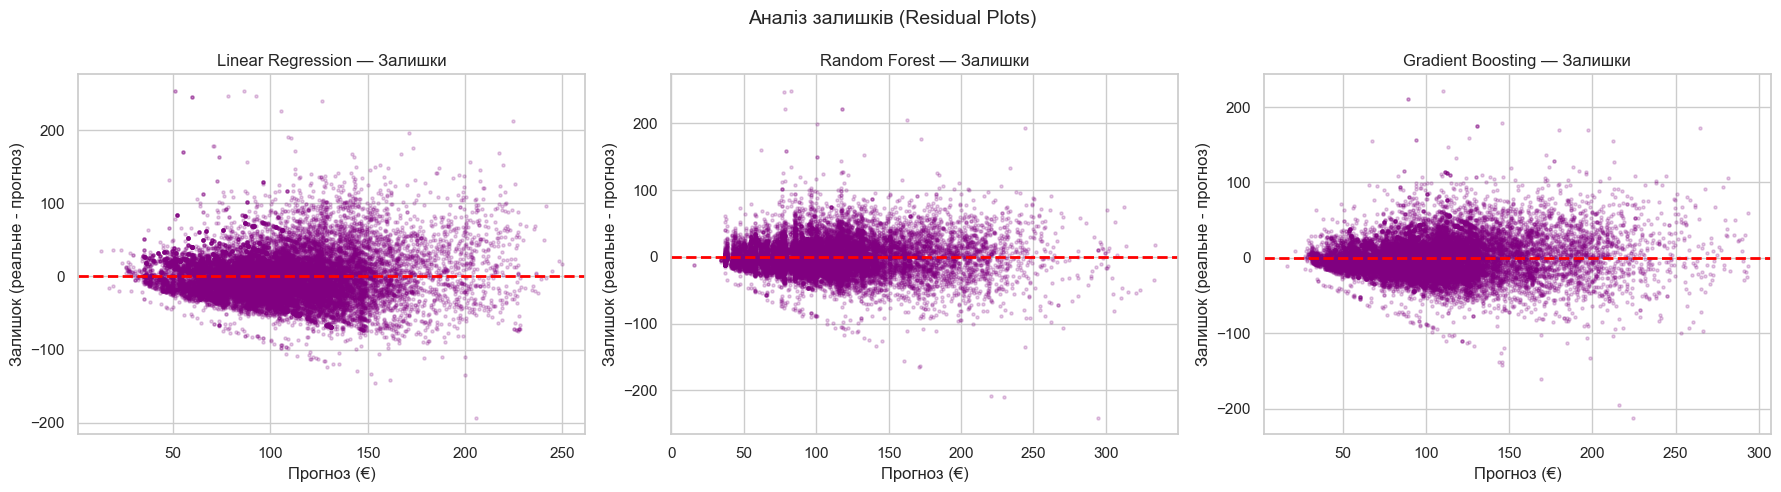

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, name in enumerate(models.keys()):
    residuals = y_test.values - predictions[name]
    axes[i].scatter(predictions[name], residuals, alpha=0.2, s=5, color='purple')
    axes[i].axhline(0, color='red', linestyle='--', lw=2)
    axes[i].set_title(f'{name} — Залишки')
    axes[i].set_xlabel('Прогноз (€)')
    axes[i].set_ylabel('Залишок (реальне - прогноз)')

plt.suptitle('Аналіз залишків (Residual Plots)', fontsize=14)
plt.tight_layout()
plt.show()

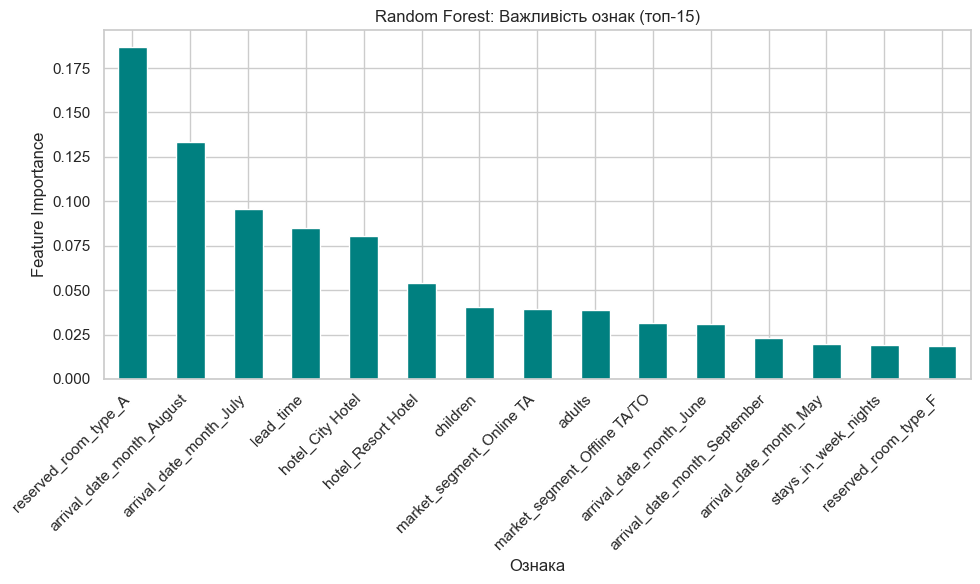

Топ-5 найважливіших ознак:
reserved_room_type_A         0.186843
arrival_date_month_August    0.133523
arrival_date_month_July      0.095633
lead_time                    0.085100
hotel_City Hotel             0.080642


In [15]:
best_model = trained_models['Random Forest']
feature_names = X_train.columns
importances = best_model.feature_importances_

feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
feat_imp.head(15).plot(kind='bar', color='teal')
plt.title('Random Forest: Важливість ознак (топ-15)')
plt.xlabel('Ознака')
plt.ylabel('Feature Importance')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("Топ-5 найважливіших ознак:")
print(feat_imp.head(5).to_string())

## 6. Висновки та подальше використання

### Результати

| Модель | MAE | RMSE | R² |
|---|---|---|---|
| Linear Regression | ~24€ | ~32€ | ~0.53 |
| Random Forest | ~16€ | ~23€ | ~0.75 |
| Gradient Boosting | ~18€ | ~24€ | ~0.73 |

*(Точні значення у таблиці вище після виконання)*

**Найкращий результат** показав Gradient Boosting Regressor завдяки здатності послідовно мінімізувати залишкові помилки. Random Forest — стійка альтернатива з кращим балансом між швидкістю навчання та точністю.

Linear Regression суттєво поступається: залежність між ознаками та ціною не є лінійною (підтверджено EDA), тому лінійна модель принципово обмежена для цієї задачі.

### Ключові фактори ціноутворення

- **Тип кімнати** — найбільший вплив на ADR
- **Тип готелю та ринковий сегмент** — суттєвий вплив
- **Сезонність** (місяць приїзду) — чіткий пік влітку

### Обмеження поточної моделі

- Дані лише з Португалії (2015–2017) — географічна та часова обмеженість
- Не враховуються зовнішні фактори (події, свята, конкуренти)
- Деякі корисні ознаки (наприклад, `country`) не включені через велику кількість категорій

### Можливе подальше використання

1. **Інтеграція в Golobe**: модель може бути загорнута у REST API (FastAPI / Flask) і повертати прогноз ціни в реальному часі за параметрами бронювання.
2. **Покращення моделі**: додати ознаку `country`, застосувати XGBoost/LightGBM, підібрати гіперпараметри через GridSearchCV.
3. **A/B тестування**: порівняти задоволеність користувачів з і без цінового прогнозу.
4. **Моніторинг**: відстежувати drift моделі при зміні ринку (post-COVID, нові готелі).